In [1]:
import pandas as pd
import seaborn as sns
import df2img
import matplotlib.pyplot as plt

In [2]:
# import and display dataset
# data has None as a categorical value but None is interpreted as a null value by pandas
data = pd.read_csv('../data/cybersecurity_intrusion_data.csv', keep_default_na=False) 
data

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


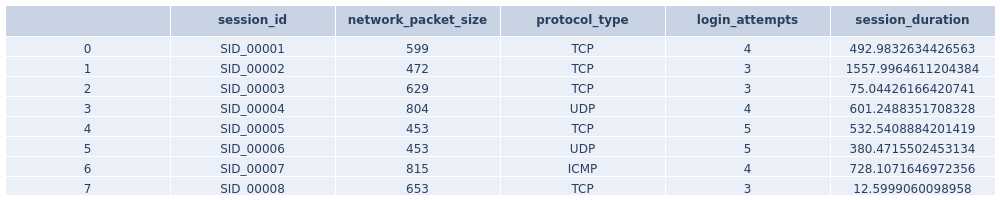

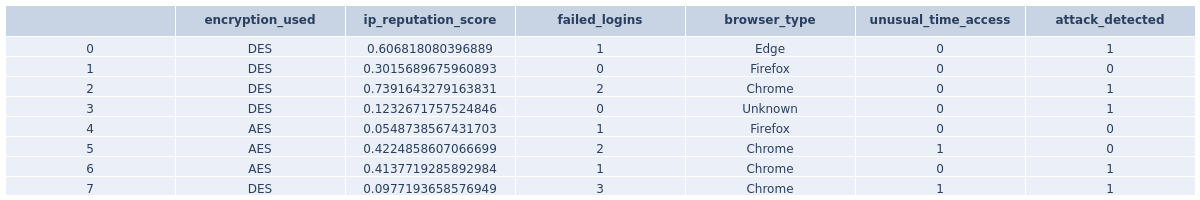

In [3]:
#save dataframe to img
data_left = data.iloc[:, :5]
data_right = data.iloc[:, 5:]
fig_left = df2img.plot_dataframe(data_left, fig_size=(1000, 200))
fig_right = df2img.plot_dataframe(data_right, fig_size=(1200, 200))
df2img.save_dataframe(fig_left, filename='../images/data_left.png')
df2img.save_dataframe(fig_right, filename='../images/data_right.png')



### Data Dictionary

- session_id: an alphanumeric ID used to uniquely identify a session. Denoted in th form SID-XXXXX where X is a number
- network_packet_size: size of network packets in bytes. Ranges from 64-1500 bytes. Smaller packets may transfer control messages while larger packets transfer bulk data. Packets exceeding 1500 bytes are broken up. An attacker may hide malicious code among split up packets.
- protocol_type: protocol used in sending packets. There are three values: TCP, UDP and ICMP
  - TCP: stands for Transmission Contol Protocol. Used for secure reliable connections. Typically used for HTTP/s and SSH.
  - UPD: stands for User Datagram Protocol. Typically used for media.
  - ICMP: stands for Internet Control Message Protocol. Used for network diagnostics. Favored for Distributed Denial Attacks.

- encryption_used: what encryption is used. Has three possible values: AES, DES, None
  - AES: stands for Advanced Encryption Standard. Common and Highly secure
  - DES: stands for Data Enctyption Standard. Less Secure standard superseded by AES
  - None: indicate unencrypted transmissions.

No or weak encryption indicates a possible attack since it allows vulnerability exploits.

- login_attempts: integer value denoting number of login attempts. High value indicates a possible dictionary attacks while low value (1-3) indicate normal usage.
- session_duration: measured in seconds. High values may indicate an attacker trying to prolong infiltration.
- failed_logins: how many login attempts failed. Multiple failed login attempts follwed by a sucessful login indicate a possible breached account.
- unusual time_access: indicates if login is on business hours. Attackers may try to avoid buisness hours to avoid detection. 
  - Assumed to be generated by Company A's system frim access time for ease of processing

- ip_reputation_score: on a scale from 0 to 1 indicates likelihood of being used for attacks of an ip address. Higher values indicate an IP used previously for known attacks
  - Assumed to be provided by Company A's threat intelligence provider
- browser_type: what web browser is used by the user. Has the following values: Edge, Safari, Firefox, Chrome and Unknown.
  - Unknown browsers may indicate attack.


## Univariate Analysis

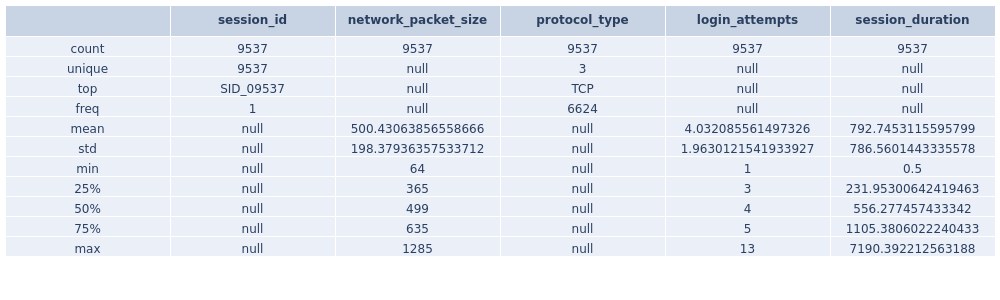

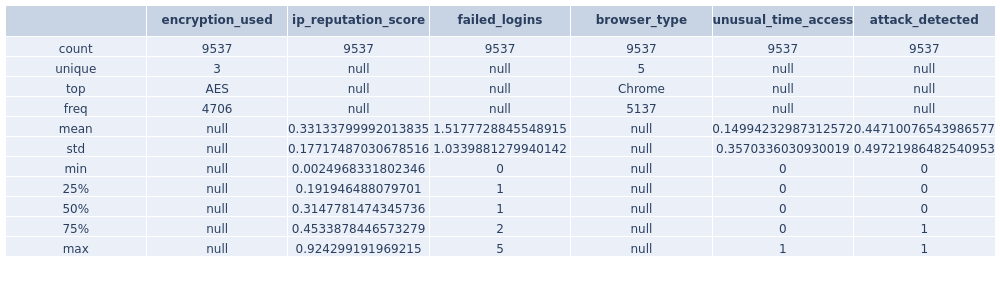

In [4]:
summary = data.describe(include='all')
summary_left = summary.iloc[:,:5]
summary_right = summary.iloc[:,5:]
fig_sum_left = df2img.plot_dataframe(summary_left, fig_size=(1000,300))
df2img.save_dataframe(fig=fig_sum_left, filename='../images/summary_left.png')
fig_sum_right = df2img.plot_dataframe(summary_right, fig_size=(1000,300))
df2img.save_dataframe(fig=fig_sum_right, filename='../images/summary_right.png')

It can be seen that there are around 9000 records that are non-null so there will be no need to clean null values

It can be seen that packet sizes do not exceed 1500 bytes which indicates low presence of DDoS in the dataset. Furthermore, login attempts has high means which might indicate a Dictionary attack.

In [5]:
info = data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


It can be seen network packet size, session duration and unusual time access have no correlation with attacks. This means: 
- Network Packet Size: attackers do not use small network packets
- Session Duration: Attackers do not stay for long(which implies that data is scraped by a script intstead of manually reading the data once illicit access is gained.)
- Unusual Time Access : Attackers try to blend in during business hours.
It can be seen that login attempts, IP reputation and failed logins have correlation with attacks. This means:
- Login Attempts, Failed Logins : Attacks try some form of guessing instead of being already known
- IP Reputation : Attacks come from IP Addresses usually used by attackers in past known attacks.

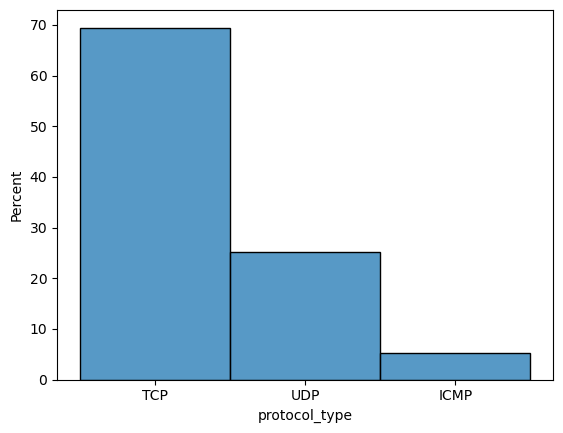

In [6]:
# Analyze Protocol data
protocol = sns.histplot(data=data['protocol_type'],stat='percent')
plt.savefig('../images/protocol.png')
plt.show()

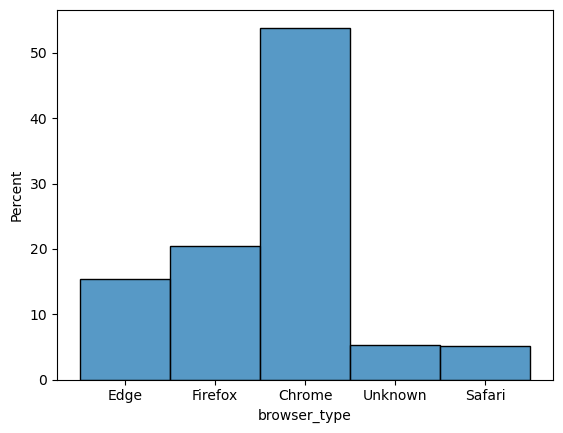

In [7]:
# Analyze browser Type
browser = sns.histplot(data=data['browser_type'], stat='percent')
plt.savefig('../images/browser.png')
plt.show()

Chrome accounts for more than half the browsers used.

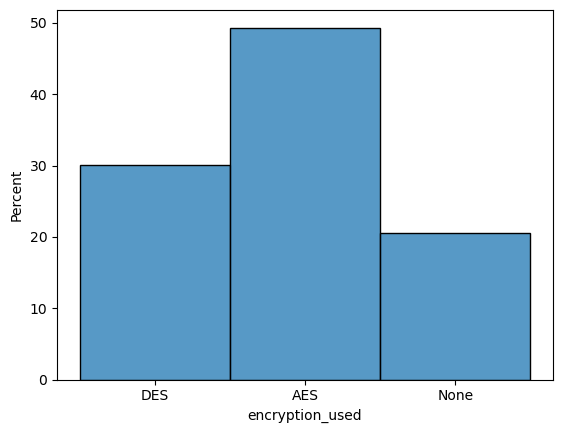

In [8]:
# Analyze encryption type
encryption = sns.histplot(data=data['encryption_used'],stat='percent')
plt.savefig('../images/encryption.png')
plt.show()

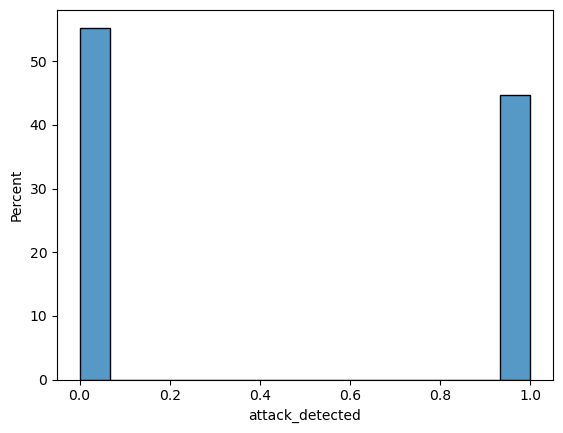

In [9]:
# Explore attacks
attack = sns.histplot(data=data['attack_detected'], stat='percent')
plt.savefig('../images/attack.png')
plt.show()

It can be seen that the classes are balanced.

# Multivariate Analysis

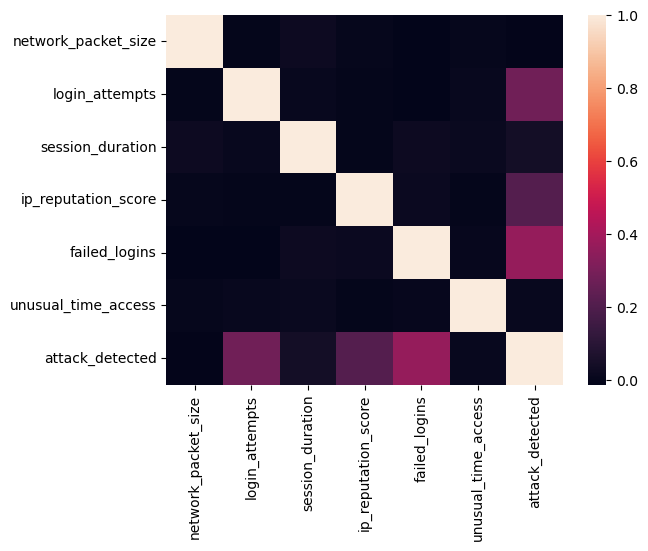

In [10]:
# Create heat map
corr_matrix = data.corr(numeric_only=True)
heatmap = sns.heatmap(corr_matrix)
plt.savefig('../images/corr_heatmap.png',bbox_inches='tight')
plt.show()


In [11]:
#separate numerical and cat features
cat = ['protocol_type', 'browser_type', 'encryption_used', 'session_id']
num = data.drop(cat, axis = 1).columns.to_list()


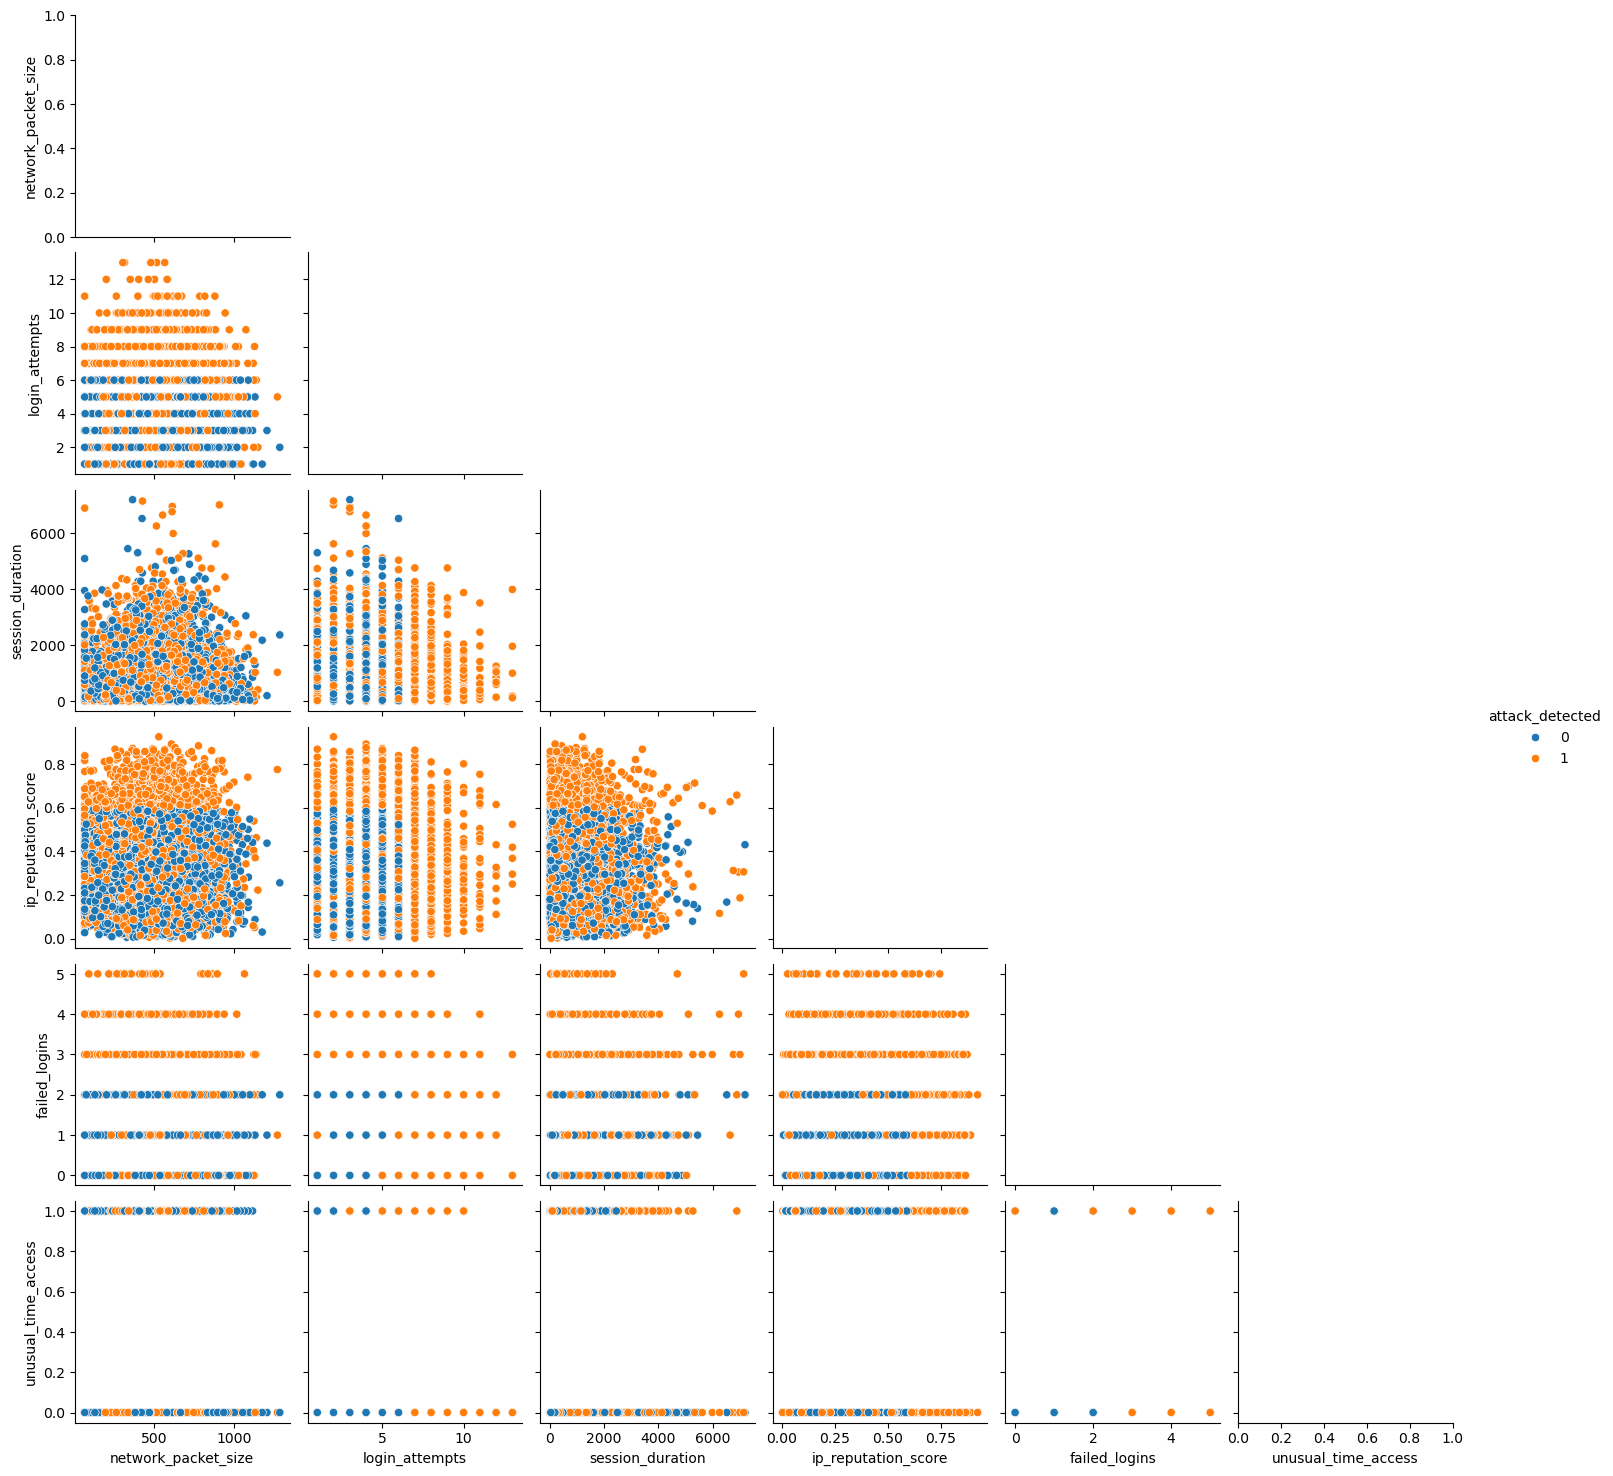

In [12]:
# Plot all numerical data using pairplot
pairplot = sns.pairplot(data=data[num], hue= 'attack_detected', diag_kind='None', corner=True)
plt.savefig('../images/pairplot.png', bbox_inches='tight')
plt.show()

It can be seen that detected attacks occur when attempted and failed logins are high. Furthermore, it can be seen that all session with IP reputation score above 0.6 are all attacks. This indicates the importance of IP reputation in detecting attacks.